## **Overview**

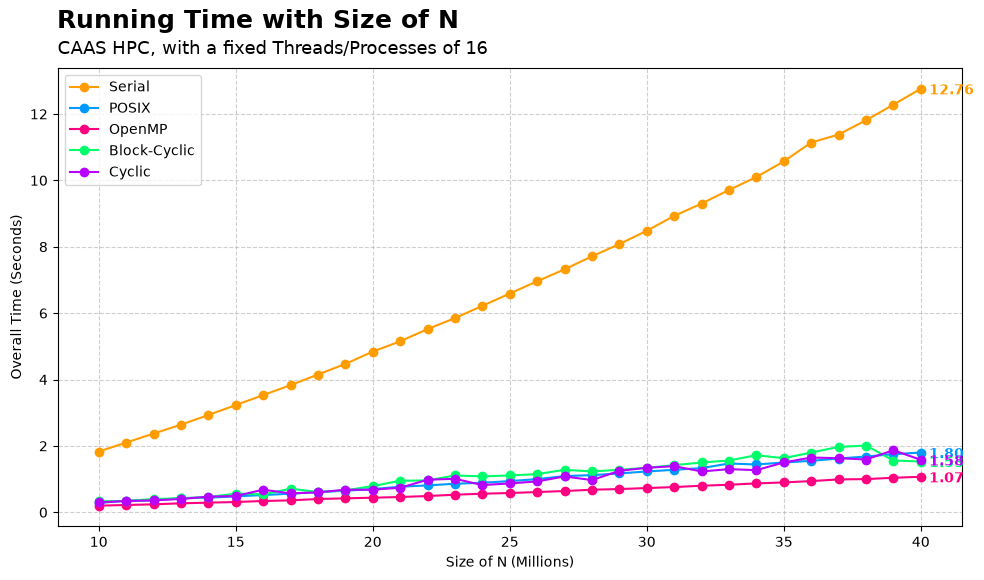

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# ADDED 'Serial Code' back to categories
categories = {
    'Serial Code': 'Serial',
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Added a 5th color (Soft Orange: #F39C12) for the Serial line
colors = ["#FF9D00", "#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and col[1] == 'Overall']
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round overall time to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Increased font sizes)
plt.suptitle("Running Time with Size of N", fontweight='bold', fontsize=18, y=0.96, ha='left', x=.062)
plt.title("CAAS HPC, with a fixed Threads/Processes of 16", fontsize=13, pad=10, loc='left')

# Axis labels and legend (Renamed X-axis)
plt.xlabel("Size of N (Millions)")
plt.ylabel("Overall Time (Seconds)")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_overview.png", dpi=300)
plt.show()

## **Graph 1**
**Comparing the running time with the increasing size of N for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

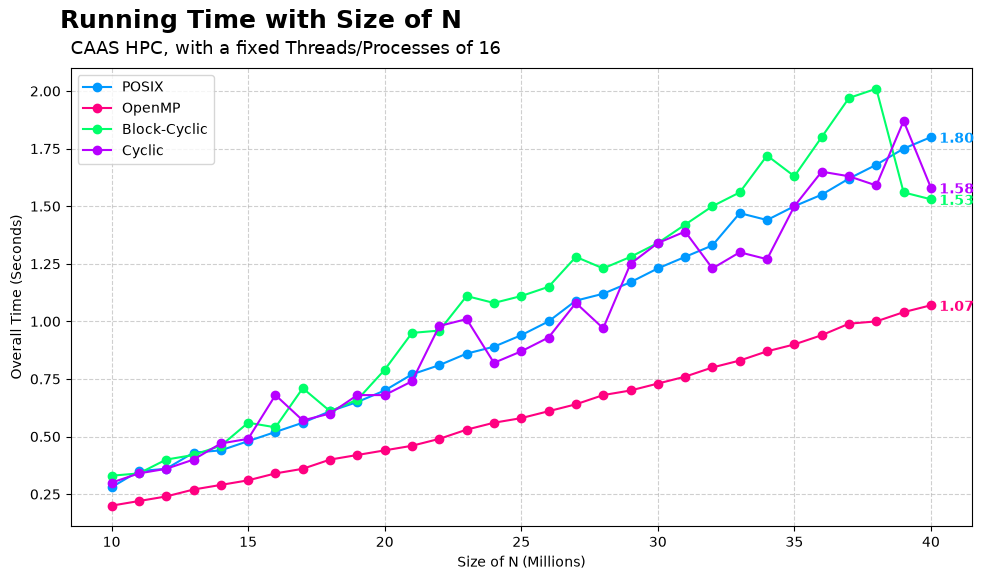

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# Removed 'Serial Code' from categories
categories = {
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Updated colors: Light Blue, Pink, Light Green, Light Purple (vibrant, not too pale)
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and col[1] == 'Overall']
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round overall time to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Increased font sizes)
plt.suptitle("Running Time with Size of N", fontweight='bold', fontsize=18, y=0.96, ha='left', x=.065)
plt.title("CAAS HPC, with a fixed Threads/Processes of 16", fontsize=13, pad=10, loc='left')

# Axis labels and legend (Renamed X-axis)
plt.xlabel("Size of N (Millions)")
plt.ylabel("Overall Time (Seconds)")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_runTime.png", dpi=300)
plt.show()

## **Graph 2**
**Comparing the empirical speedup with the increasing size of N for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

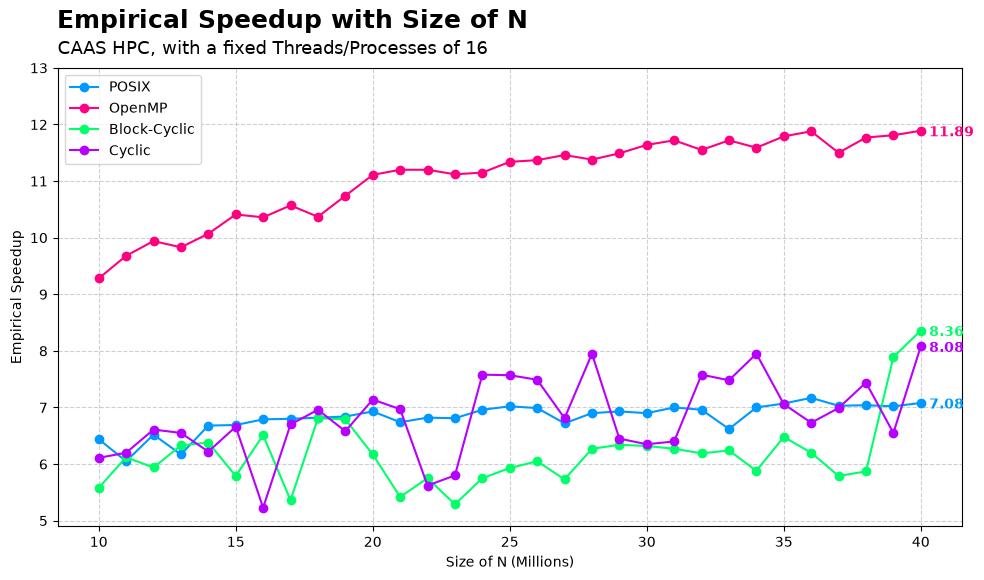

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# Categories for Empirical Speedup
categories = {
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    # Find the matching column for the current category and its 'E Speedup' sub-column
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and 'E Speedup' in str(col[1])]
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round empirical speedup to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Size of N", fontweight='bold', fontsize=18, x=.062, y=.96, ha='left')
plt.title("CAAS HPC, with a fixed Threads/Processes of 16", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Size of N (Millions)")
plt.ylabel("Empirical Speedup")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Set Y-axis limit so the max is 12 (starts at 0 by default, adjusting top only)
plt.ylim(top=13)

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_eSpeedup_N.png", dpi=300)
plt.show()

## **Graph 3**
**Comparing the empirical speedup with the increasing number of threads/processes for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

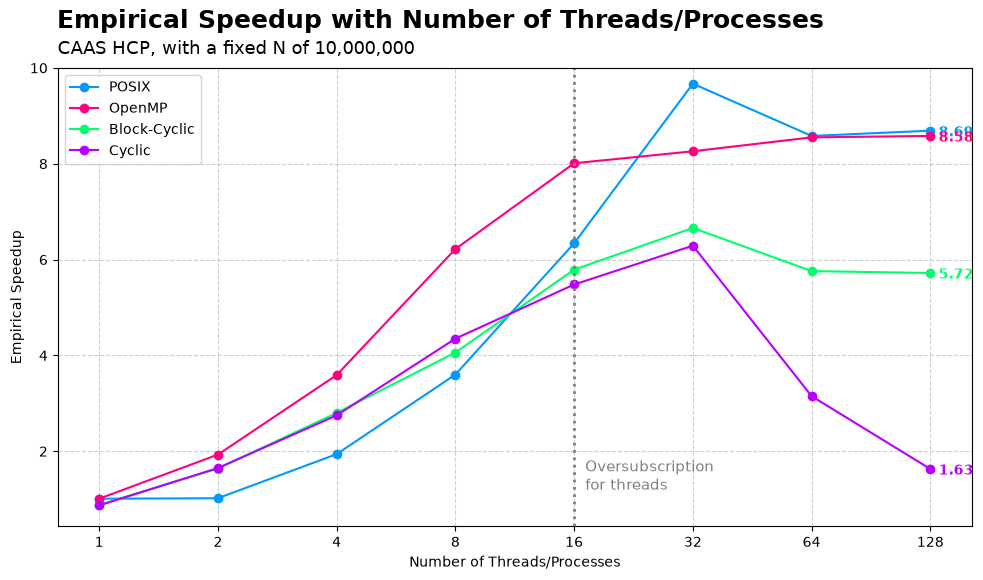

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[36, 37])

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
# We explicitly target the T/P column and the specific E Speedup columns
tp_col = df.columns[0]
target_cols = [tp_col]

categories = {
    'POSIX': 'POSIX',
    'OpenMP': 'OpenMP',
    'Open MPI Block-Cyclic': 'Block-Cyclic',
    'Open MPI Cyclic': 'Cyclic'
}

# Dynamically find the exact columns to keep
for cat in categories.keys():
    # Find the E Speedup column for this category
    es_col = [c for c in df.columns if isinstance(c[0], str) and cat in c[0] and 'E Speedup' in str(c[1])][0]
    target_cols.append(es_col)

# Create the clean dataframe with ONLY the necessary columns
df_clean = df[target_cols].copy()

# Rename headers to a flat, clean format so it's easy to reference
df_clean.columns = ['T/P'] + list(categories.values())

# Convert all columns to numeric to wipe out any text artifacts or spaces
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Filter the T/P column strictly to our expected range (1 to 128)
df_clean = df_clean.dropna(subset=['T/P'])
df_clean = df_clean[(df_clean['T/P'] > 0) & (df_clean['T/P'] <= 128)]
df_clean = df_clean.sort_values(by='T/P').reset_index(drop=True)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
plt.figure(figsize=(10, 6))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, round, and plot each line safely
for idx, legend_label in enumerate(categories.values()):
    color = colors[idx]
    
    # Isolate X and Y, and drop NaNs just for this specific line 
    # (Prevents one missing data point from ruining the whole row)
    temp_df = df_clean[['T/P', legend_label]].dropna()
    
    x_vals = temp_df['T/P'].tolist()
    y_vals = temp_df[legend_label].round(2).tolist()
    
    if len(x_vals) > 0:
        # Plot the line with dot points
        plt.plot(x_vals, y_vals, marker='o', label=legend_label, color=color)
        
        # Annotate the last dot point with its value
        plt.annotate(f'{y_vals[-1]:.2f}', 
                     xy=(x_vals[-1], y_vals[-1]), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Number of Threads/Processes", fontweight='bold', fontsize=18, x=0.062, y=0.96, ha='left')
plt.title("CAAS HCP, with a fixed Threads/Processes of 16", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Threads/Processes")
plt.ylabel("Empirical Speedup")
plt.legend()

# Add a dotted vertical line at x=16 and its wrapped label at the top right
plt.axvline(x=16, color='gray', linestyle=':', linewidth=2)
plt.annotate('Oversubscription\nfor threads', 
             xy=(16, 2),            # Position at the top of the Y-axis
             xytext=(8, -5),         # Offset 8 points to the right and slightly down
             textcoords='offset points',
             va='top',               # Align text from the top so it drops down
             ha='left',              # Align left to the offset
             color='gray',
             fontsize=11)

# Set X-axis to a Base-2 Logarithmic scale to evenly space 1, 2, 4, 8, 16...
plt.xscale('log', base=2)

# Set X-axis ticks explicitly and force them to render as plain numbers
ticks = [1, 2, 4, 8, 16, 32, 64, 128]
plt.xticks(ticks, labels=[str(t) for t in ticks])

# Set Y-axis limit so the max is 10
plt.ylim(top=10)

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("task1_eSpeedup_TP.png", dpi=300)
plt.show()

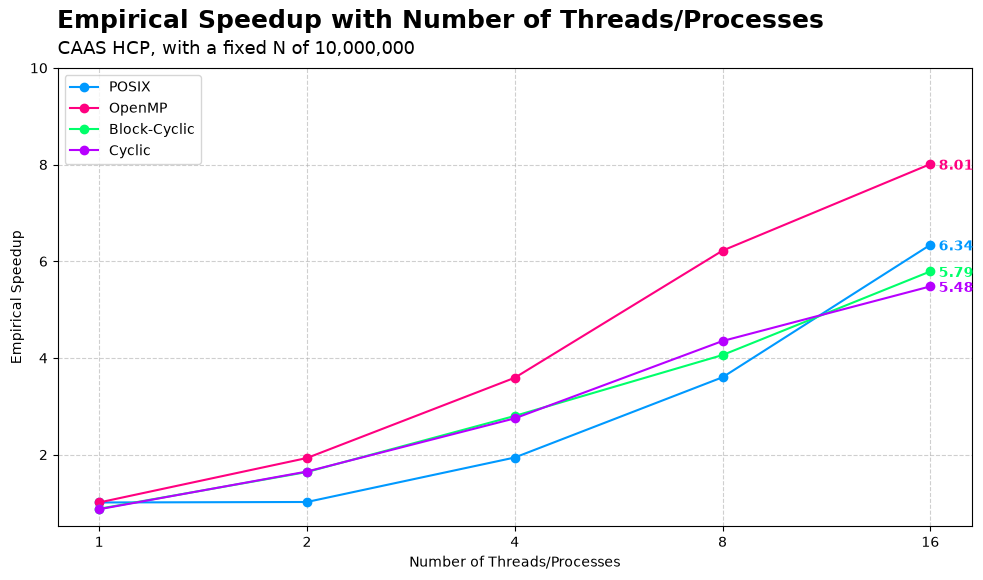

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[36, 37])

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
# We explicitly target the T/P column and the specific E Speedup columns
tp_col = df.columns[0]
target_cols = [tp_col]

categories = {
    'POSIX': 'POSIX',
    'OpenMP': 'OpenMP',
    'Open MPI Block-Cyclic': 'Block-Cyclic',
    'Open MPI Cyclic': 'Cyclic'
}

# Dynamically find the exact columns to keep
for cat in categories.keys():
    # Find the E Speedup column for this category
    es_col = [c for c in df.columns if isinstance(c[0], str) and cat in c[0] and 'E Speedup' in str(c[1])][0]
    target_cols.append(es_col)

# Create the clean dataframe with ONLY the necessary columns
df_clean = df[target_cols].copy()

# Rename headers to a flat, clean format so it's easy to reference
df_clean.columns = ['T/P'] + list(categories.values())

# Convert all columns to numeric to wipe out any text artifacts or spaces
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Filter the T/P column strictly to our expected range (1 to 128)
df_clean = df_clean.dropna(subset=['T/P'])
df_clean = df_clean[(df_clean['T/P'] > 0) & (df_clean['T/P'] <= 16)]
df_clean = df_clean.sort_values(by='T/P').reset_index(drop=True)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
plt.figure(figsize=(10, 6))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]

# 3. Extract, round, and plot each line safely
for idx, legend_label in enumerate(categories.values()):
    color = colors[idx]
    
    # Isolate X and Y, and drop NaNs just for this specific line 
    # (Prevents one missing data point from ruining the whole row)
    temp_df = df_clean[['T/P', legend_label]].dropna()
    
    x_vals = temp_df['T/P'].tolist()
    y_vals = temp_df[legend_label].round(2).tolist()
    
    if len(x_vals) > 0:
        # Plot the line with dot points
        plt.plot(x_vals, y_vals, marker='o', label=legend_label, color=color)
        
        # Annotate the last dot point with its value
        plt.annotate(f'{y_vals[-1]:.2f}', 
                     xy=(x_vals[-1], y_vals[-1]), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Number of Threads/Processes", fontweight='bold', fontsize=18, x=0.062, y=0.96, ha='left')
plt.title("CAAS HCP, with a fixed N of 10,000,000", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Threads/Processes")
plt.ylabel("Empirical Speedup")
plt.legend()

# Set X-axis to a Base-2 Logarithmic scale to evenly space 1, 2, 4, 8, 16...
plt.xscale('log', base=2)

# Set X-axis ticks explicitly and force them to render as plain numbers
ticks = [1, 2, 4, 8, 16]
plt.xticks(ticks, labels=[str(t) for t in ticks])

# Set Y-axis limit so the max is 10
plt.ylim(top=10)

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task1_eSpeedup_TP.png", dpi=300)
plt.show()

## **Graph 4**
**Comparing the empirical speedup with the increasing number of threads for Open MPI and Hybrid (fixed processes of 4).**

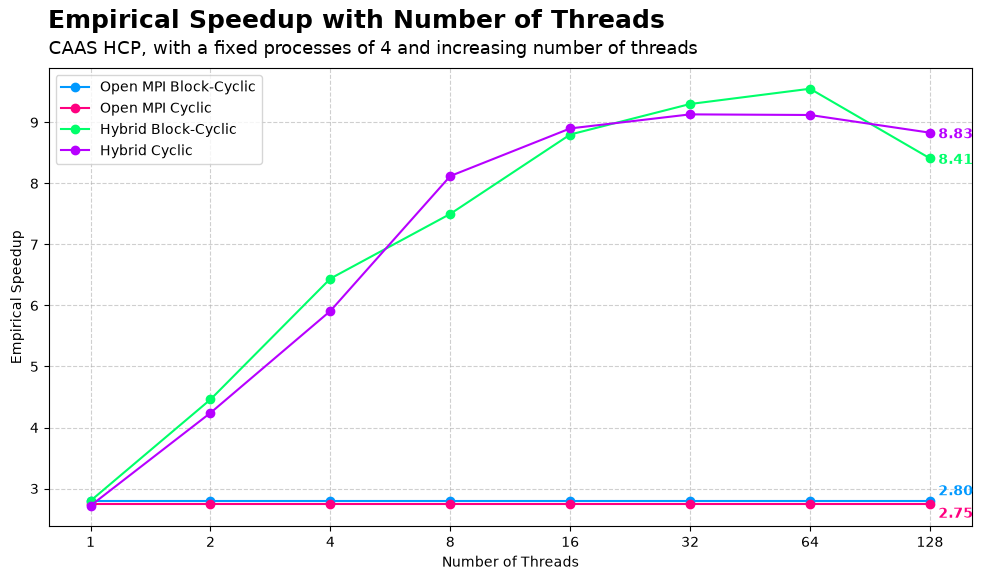

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx" # Update to your exact file name
df = pd.read_excel(file_name, sheet_name="CAAS", header=[36, 37])

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
tp_col = df.columns[0]
target_cols = [tp_col]

categories = [
    'Open MPI Block-Cyclic',
    'Open MPI Cyclic',
    'Hybrid Block-Cyclic',
    'Hybrid Cyclic'
]

# Find ONLY the E Speedup columns for each category
for cat in categories:
    es_col = [c for c in df.columns if isinstance(c[0], str) and cat in c[0] and 'E Speedup' in str(c[1])][0]
    target_cols.append(es_col)

# Create the clean dataframe with our 5 target columns
df_clean = df[target_cols].copy()

# Rename headers to a flat, clean format so it's easy to reference
df_clean.columns = [
    'T/P', 
    'Open MPI Block-Cyclic E Speedup', 
    'Open MPI Cyclic E Speedup',
    'Hybrid Block-Cyclic E Speedup',
    'Hybrid Cyclic E Speedup'
]

# Convert ALL columns to numeric to wipe out any text artifacts
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop missing T/P values and filter strictly to the 1-128 range
df_clean = df_clean.dropna(subset=['T/P'])
df_clean = df_clean[(df_clean['T/P'] > 0) & (df_clean['T/P'] <= 128)]
df_clean = df_clean.sort_values(by='T/P').reset_index(drop=True)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
plt.figure(figsize=(10, 6))

colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]
x_standard = [1, 2, 4, 8, 16, 32, 64, 128] # Standard X-axis ticks

for idx, cat in enumerate(categories):
    color = colors[idx]
    speedup_col = f"{cat} E Speedup"
    
    if 'Open MPI' in cat:
        # --- BASELINE LOGIC ---
        # Extract the value at T/P = 4 (the orange row)
        baseline_array = df_clean.loc[df_clean['T/P'] == 4, speedup_col].values
        
        if len(baseline_array) > 0:
            baseline_val = float(baseline_array[0])
            x_vals = x_standard
            y_vals = [round(baseline_val, 2)] * len(x_standard)
        else:
            x_vals, y_vals = [], []
            
    else:
        # --- HYBRID LOGIC ---
        # Now mapping directly to the main T/P column
        temp_df = df_clean[['T/P', speedup_col]].dropna()
        
        x_vals = temp_df['T/P'].tolist()
        y_vals = temp_df[speedup_col].round(2).tolist()
        
    # Plot if data is found
    if len(x_vals) > 0:
        plt.plot(x_vals, y_vals, marker='o', label=cat, color=color)
        
        # Determine specific text offset to avoid overlap
        if cat == 'Open MPI Block-Cyclic':
            text_offset = (6, 4)   # Push slightly up
        elif cat == 'Open MPI Cyclic':
            text_offset = (6, -10) # Push slightly down
        else:
            text_offset = (6, -4)  # Default offset for the others
            
        # Annotate the last dot point
        plt.annotate(f'{y_vals[-1]:.2f}', 
                     xy=(x_vals[-1], y_vals[-1]), 
                     xytext=text_offset,
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Number of Threads", fontweight='bold', fontsize=18, x=0.053, y=0.96, ha='left')
plt.title("CAAS HCP, with a fixed processes of 4 and increasing number of threads", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Threads")
plt.ylabel("Empirical Speedup")
plt.legend()

# Set X-axis to a Base-2 Logarithmic scale
plt.xscale('log', base=2)
plt.xticks(x_standard, labels=[str(t) for t in x_standard])

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("task2_eSpeedup_Hybrid_fixed_process4.png", dpi=300)
plt.show()

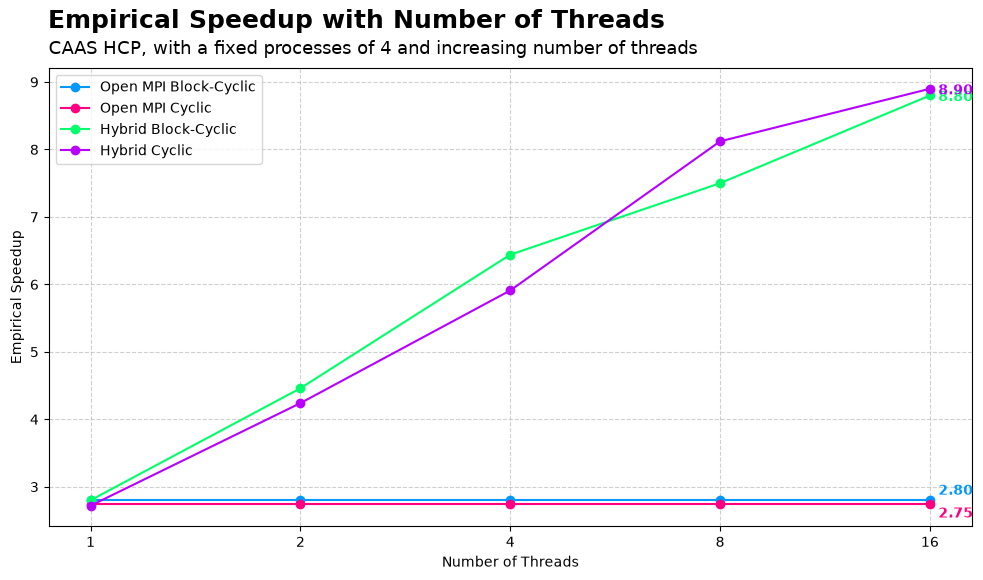

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx" # Update to your exact file name
df = pd.read_excel(file_name, sheet_name="CAAS", header=[36, 37])

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
tp_col = df.columns[0]
target_cols = [tp_col]

categories = [
    'Open MPI Block-Cyclic',
    'Open MPI Cyclic',
    'Hybrid Block-Cyclic',
    'Hybrid Cyclic'
]

# Find ONLY the E Speedup columns for each category
for cat in categories:
    es_col = [c for c in df.columns if isinstance(c[0], str) and cat in c[0] and 'E Speedup' in str(c[1])][0]
    target_cols.append(es_col)

# Create the clean dataframe with our 5 target columns
df_clean = df[target_cols].copy()

# Rename headers to a flat, clean format so it's easy to reference
df_clean.columns = [
    'T/P', 
    'Open MPI Block-Cyclic E Speedup', 
    'Open MPI Cyclic E Speedup',
    'Hybrid Block-Cyclic E Speedup',
    'Hybrid Cyclic E Speedup'
]

# Convert ALL columns to numeric to wipe out any text artifacts
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop missing T/P values and filter strictly to the 1-128 range
df_clean = df_clean.dropna(subset=['T/P'])
df_clean = df_clean[(df_clean['T/P'] > 0) & (df_clean['T/P'] <= 16)]
df_clean = df_clean.sort_values(by='T/P').reset_index(drop=True)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
plt.figure(figsize=(10, 6))

colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]
x_standard = [1, 2, 4, 8, 16] # Standard X-axis ticks

for idx, cat in enumerate(categories):
    color = colors[idx]
    speedup_col = f"{cat} E Speedup"
    
    if 'Open MPI' in cat:
        # --- BASELINE LOGIC ---
        # Extract the value at T/P = 4 (the orange row)
        baseline_array = df_clean.loc[df_clean['T/P'] == 4, speedup_col].values
        
        if len(baseline_array) > 0:
            baseline_val = float(baseline_array[0])
            x_vals = x_standard
            y_vals = [round(baseline_val, 2)] * len(x_standard)
        else:
            x_vals, y_vals = [], []
            
    else:
        # --- HYBRID LOGIC ---
        # Now mapping directly to the main T/P column
        temp_df = df_clean[['T/P', speedup_col]].dropna()
        
        x_vals = temp_df['T/P'].tolist()
        y_vals = temp_df[speedup_col].round(2).tolist()
        
    # Plot if data is found
    if len(x_vals) > 0:
        plt.plot(x_vals, y_vals, marker='o', label=cat, color=color)
        
        # Determine specific text offset to avoid overlap
        if cat == 'Open MPI Block-Cyclic':
            text_offset = (6, 4)   # Push slightly up
        elif cat == 'Open MPI Cyclic':
            text_offset = (6, -10) # Push slightly down
        else:
            text_offset = (6, -4)  # Default offset for the others
            
        # Annotate the last dot point
        plt.annotate(f'{y_vals[-1]:.2f}', 
                     xy=(x_vals[-1], y_vals[-1]), 
                     xytext=text_offset,
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Number of Threads", fontweight='bold', fontsize=18, x=0.053, y=0.96, ha='left')
plt.title("CAAS HCP, with a fixed processes of 4 and increasing number of threads", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Threads")
plt.ylabel("Empirical Speedup")
plt.legend()

# Set X-axis to a Base-2 Logarithmic scale
plt.xscale('log', base=2)
plt.xticks(x_standard, labels=[str(t) for t in x_standard])

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task2_eSpeedup_Hybrid_fixed_process4.png", dpi=300)
plt.show()

## **Graph 5**
**Comparing the empirical speedup with the increasing number of procesees and threads for Hybrid, increasing number of threads for POSIX and OpenMP.**

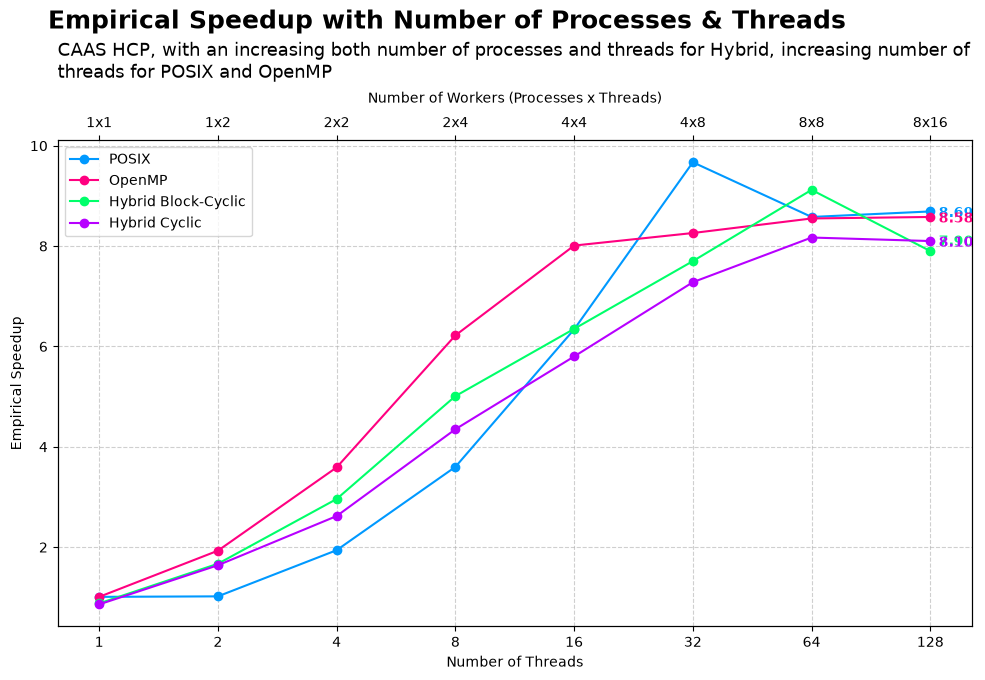

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[36, 37])

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
# Target the main T/P column
tp_col = df.columns[0]
target_cols = [tp_col]

# Match the exact top-level headers from your new Excel screenshot
categories = {
    'POSIX': 'POSIX',
    'OpenMP': 'OpenMP',
    'Hybrid Block-Cyclic (Ttl Workers)': 'Hybrid Block-Cyclic',
    'Hybrid Cyclic (Ttl Workers)': 'Hybrid Cyclic'
}

# Dynamically find the exact 'E Speedup' columns for our target lines
for cat_key in categories.keys():
    es_cols = [c for c in df.columns if isinstance(c[0], str) and cat_key in c[0] and 'E Speedup' in str(c[1])]
    if es_cols:
        target_cols.append(es_cols[0])

# Create the clean dataframe with ONLY the necessary columns
df_clean = df[target_cols].copy()

# Rename headers to a flat, clean format so it's easy to reference
df_clean.columns = ['T/P'] + list(categories.values())

# Convert all columns to numeric to wipe out any text artifacts or spaces
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Filter the T/P column strictly to our expected range (1 to 128)
df_clean = df_clean.dropna(subset=['T/P'])
df_clean = df_clean[(df_clean['T/P'] >= 1) & (df_clean['T/P'] <= 128)]
df_clean = df_clean.sort_values(by='T/P').reset_index(drop=True)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
# We use subplots here to easily manage the twin (top) axis
fig, ax1 = plt.subplots(figsize=(10, 7))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]
x_standard = [1, 2, 4, 8, 16, 32, 64, 128] 
top_labels = ["1x1", "1x2", "2x2", "2x4", "4x4", "4x8", "8x8", "8x16"]

# Extract, round, and plot each line safely on ax1
for idx, legend_label in enumerate(categories.values()):
    color = colors[idx]
    
    # Isolate X and Y, dropping NaNs for this specific line
    temp_df = df_clean[['T/P', legend_label]].dropna()
    
    x_vals = temp_df['T/P'].tolist()
    y_vals = temp_df[legend_label].round(2).tolist()
    
    if len(x_vals) > 0:
        # Plot the line with dot points
        ax1.plot(x_vals, y_vals, marker='o', label=legend_label, color=color)
        
        # Add slight text offset checks to prevent annotations from heavily overlapping
        text_offset = (6, -4)
        if legend_label == 'Hybrid Block-Cyclic':
            text_offset = (6, 4) # Push slightly up
            
        # Annotate the last dot point with its value
        ax1.annotate(f'{y_vals[-1]:.2f}', 
                     xy=(x_vals[-1], y_vals[-1]), 
                     xytext=text_offset,
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Number of Processes & Threads", fontweight='bold', fontsize=18, x=0.053, y=0.965, ha='left')
plt.title("CAAS HCP, with an increasing both number of processes and threads for Hybrid, increasing number of \nthreads for POSIX and OpenMP", 
          fontsize=13, pad=10, loc='left') # pad=35 leaves room for the top axis

# --- BOTTOM AXIS FORMATTING (ax1) ---
ax1.set_xlabel("Number of Threads")
ax1.set_ylabel("Empirical Speedup")
ax1.set_xscale('log', base=2)
ax1.set_xticks(x_standard)
ax1.set_xticklabels([str(t) for t in x_standard])
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- TOP AXIS FORMATTING (ax2) ---
ax2 = ax1.twiny() # Create a second axis that shares the same Y-axis
ax2.set_xscale('log', base=2)
ax2.set_xlim(ax1.get_xlim()) # Force limits to be exactly the same as bottom axis
ax2.set_xticks(x_standard)
ax2.set_xticklabels(top_labels)
ax2.set_xlabel("Number of Workers (Processes x Threads)", labelpad=10)

plt.tight_layout()
# plt.savefig("task2_eSpeedup_Hybrid_Thread.png", dpi=300)
plt.show()

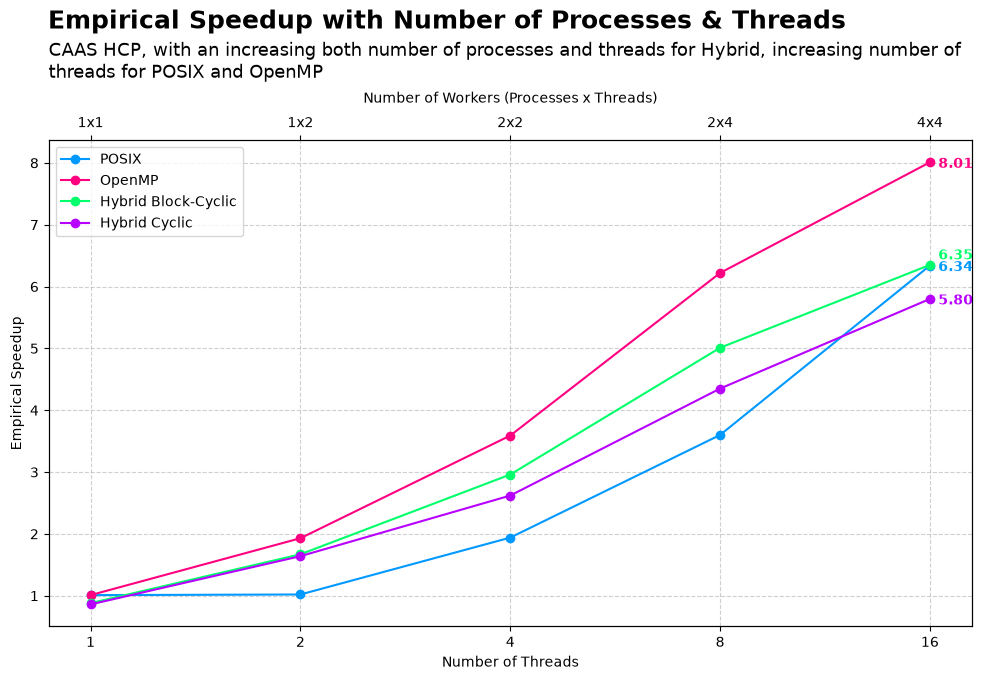

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[36, 37])

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
# Target the main T/P column
tp_col = df.columns[0]
target_cols = [tp_col]

# Match the exact top-level headers from your new Excel screenshot
categories = {
    'POSIX': 'POSIX',
    'OpenMP': 'OpenMP',
    'Hybrid Block-Cyclic (Ttl Workers)': 'Hybrid Block-Cyclic',
    'Hybrid Cyclic (Ttl Workers)': 'Hybrid Cyclic'
}

# Dynamically find the exact 'E Speedup' columns for our target lines
for cat_key in categories.keys():
    es_cols = [c for c in df.columns if isinstance(c[0], str) and cat_key in c[0] and 'E Speedup' in str(c[1])]
    if es_cols:
        target_cols.append(es_cols[0])

# Create the clean dataframe with ONLY the necessary columns
df_clean = df[target_cols].copy()

# Rename headers to a flat, clean format so it's easy to reference
df_clean.columns = ['T/P'] + list(categories.values())

# Convert all columns to numeric to wipe out any text artifacts or spaces
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Filter the T/P column strictly to our expected range (1 to 128)
df_clean = df_clean.dropna(subset=['T/P'])
df_clean = df_clean[(df_clean['T/P'] >= 1) & (df_clean['T/P'] <= 16)]
df_clean = df_clean.sort_values(by='T/P').reset_index(drop=True)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
# We use subplots here to easily manage the twin (top) axis
fig, ax1 = plt.subplots(figsize=(10, 7))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ["#0099FF", "#FF0080", "#00FF6A", "#B700FF"]
x_standard = [1, 2, 4, 8, 16] 
top_labels = ["1x1", "1x2", "2x2", "2x4", "4x4"]

# Extract, round, and plot each line safely on ax1
for idx, legend_label in enumerate(categories.values()):
    color = colors[idx]
    
    # Isolate X and Y, dropping NaNs for this specific line
    temp_df = df_clean[['T/P', legend_label]].dropna()
    
    x_vals = temp_df['T/P'].tolist()
    y_vals = temp_df[legend_label].round(2).tolist()
    
    if len(x_vals) > 0:
        # Plot the line with dot points
        ax1.plot(x_vals, y_vals, marker='o', label=legend_label, color=color)
        
        # Add slight text offset checks to prevent annotations from heavily overlapping
        text_offset = (6, -4)
        if legend_label == 'Hybrid Block-Cyclic':
            text_offset = (6, 4) # Push slightly up
            
        # Annotate the last dot point with its value
        ax1.annotate(f'{y_vals[-1]:.2f}', 
                     xy=(x_vals[-1], y_vals[-1]), 
                     xytext=text_offset,
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup with Number of Processes & Threads", fontweight='bold', fontsize=18, x=0.053, y=0.965, ha='left')
plt.title("CAAS HCP, with an increasing both number of processes and threads for Hybrid, increasing number of \nthreads for POSIX and OpenMP", 
          fontsize=13, pad=10, loc='left') # pad=35 leaves room for the top axis

# --- BOTTOM AXIS FORMATTING (ax1) ---
ax1.set_xlabel("Number of Threads")
ax1.set_ylabel("Empirical Speedup")
ax1.set_xscale('log', base=2)
ax1.set_xticks(x_standard)
ax1.set_xticklabels([str(t) for t in x_standard])
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- TOP AXIS FORMATTING (ax2) ---
ax2 = ax1.twiny() # Create a second axis that shares the same Y-axis
ax2.set_xscale('log', base=2)
ax2.set_xlim(ax1.get_xlim()) # Force limits to be exactly the same as bottom axis
ax2.set_xticks(x_standard)
ax2.set_xticklabels(top_labels)
ax2.set_xlabel("Number of Workers (Processes x Threads)", labelpad=10)

plt.tight_layout()
plt.savefig("task2_eSpeedup_Hybrid_Thread.png", dpi=300)
plt.show()

## **Graph 6**
**Comparing the empirical speedup and theoretical speedup (Amdahl's Law) with an increasing number of processes.**

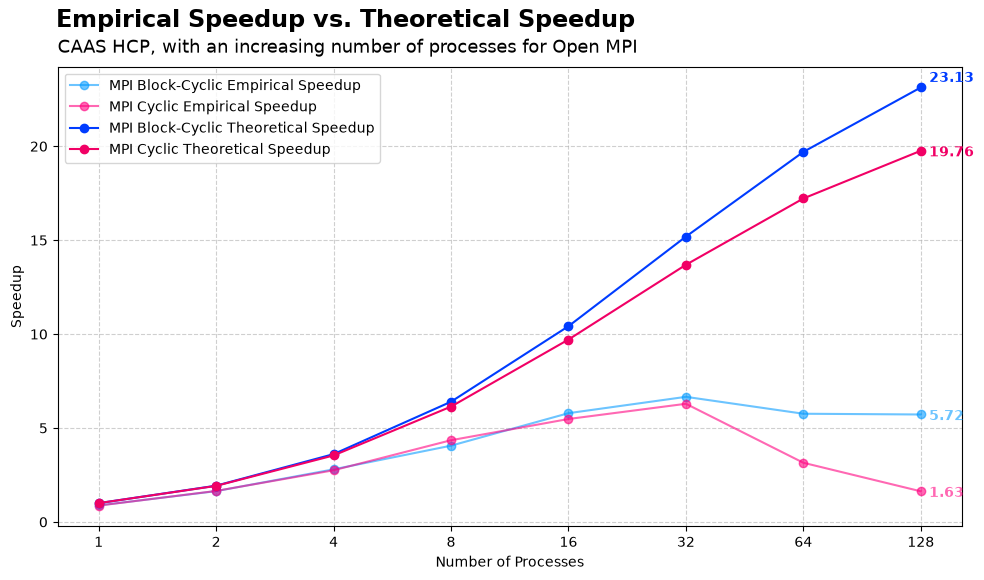

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "task3.xlsx"

# Read the file without headers first so we can explicitly slice the exact block of data
# This completely ignores merged headers and formula artifacts
df_raw = pd.read_excel(file_name, sheet_name="Data", header=None)

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
# Extract Rows 38 to 45 (Pandas index 37 to 44)
# Col 0: T/P
# Col 4: Open MPI Block Cyclic - E Speedup
# Col 5: Open MPI Block Cyclic - Amdahl (Theoretical)
# Col 9: Open MPI Cyclic - E Speedup
# Col 10: Open MPI Cyclic - Amdahl (Theoretical)
target_cols = [0, 4, 5, 9, 10]
df_clean = df_raw.iloc[37:45, target_cols].copy()

# Rename to explicit names for easy plotting
df_clean.columns = [
    'Number of Processes',
    'MPI Block-Cyclic Empirical Speedup',
    'MPI Block-Cyclic Theoretical Speedup',
    'MPI Cyclic Empirical Speedup',
    'MPI Cyclic Theoretical Speedup'
]

# Convert all columns to numeric to wipe out any string artifacts or formula references
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop any entirely empty rows and ensure X-axis points are sorted
df_clean = df_clean.dropna(subset=['Number of Processes'])
df_clean = df_clean.sort_values(by='Number of Processes').reset_index(drop=True)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
plt.figure(figsize=(10, 6))

# Define colors: light blue, pink, light green, light purple
colors = ["#0099FF93", "#FF008097", "#003CFF", "#F10065"]
x_standard = [1, 2, 4, 8, 16, 32, 64, 128] # Logarithmic ticks

# Extract X values
x_vals = df_clean['Number of Processes'].tolist()

# Plot each of the 4 lines
lines_to_plot = [
    'MPI Block-Cyclic Empirical Speedup',
    'MPI Cyclic Empirical Speedup',
    'MPI Block-Cyclic Theoretical Speedup',
    'MPI Cyclic Theoretical Speedup'
]

for idx, line_name in enumerate(lines_to_plot):
    color = colors[idx]
    
    # Extract Y values and round to 2 decimal places
    y_vals = df_clean[line_name].round(2).tolist()
    
    # Plot the line with dot points
    plt.plot(x_vals, y_vals, marker='o', label=line_name, color=color)
    
    # Annotate the last dot point (handle overlaps slightly by adjusting offsets)
    text_offset = (6, -4)
    if 'Theoretical' in line_name and 'Block' in line_name:
        text_offset = (6, 4) # Push one of the overlapping theoretical lines up
    
    plt.annotate(f'{y_vals[-1]:.2f}', 
                 xy=(x_vals[-1], y_vals[-1]), 
                 xytext=text_offset,
                 textcoords='offset points',
                 color=color, 
                 fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup vs. Theoretical Speedup", fontweight='bold', fontsize=17, x=0.061, y=0.96, ha='left')
plt.title("CAAS HCP, with an increasing number of processes for Open MPI", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Processes")
plt.ylabel("Speedup")
plt.legend(loc='upper left')

# Set X-axis to a Base-2 Logarithmic scale
plt.xscale('log', base=2)
plt.xticks(x_standard, labels=[str(t) for t in x_standard])

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task3_etspeedup_MPI.png", dpi=300)
plt.show()

## **Graph 7**
**Comparing the empirical speedup and theoretical speedup (Amdahl's Law) with an increasing number of processes.**

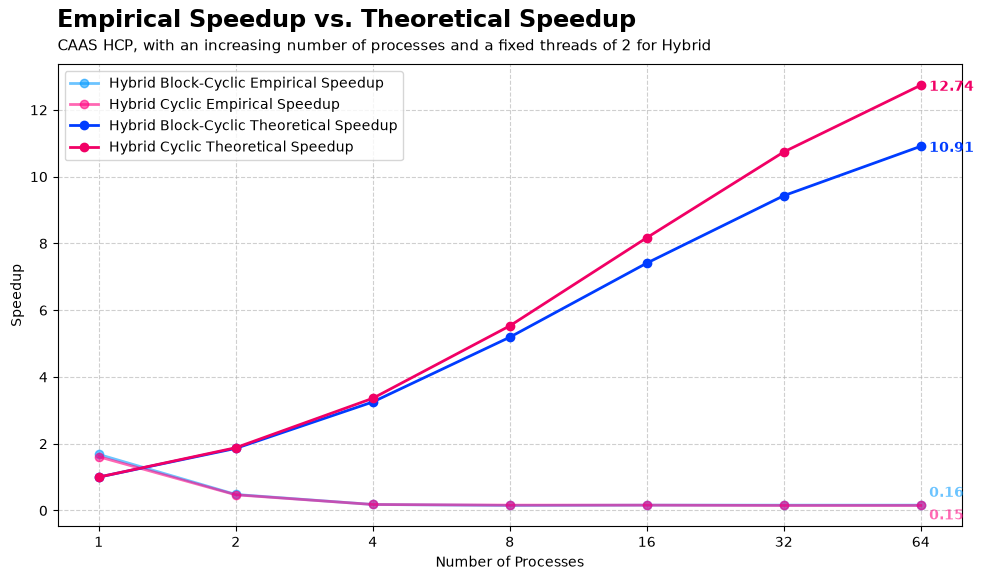

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "task3.xlsx"

# Read the file without headers to explicitly slice the exact block of data
df_raw = pd.read_excel(file_name, sheet_name="Data", header=None)

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
target_cols = [0, 14, 15, 19, 20]

# Pandas is 0-indexed, so rows 38 to 45 correspond to iloc[37:45]
df_clean = df_raw.iloc[37:45, target_cols].copy()

# Rename to explicit names for easy plotting
df_clean.columns = [
    'Number of Processes',
    'Hybrid Block-Cyclic Empirical Speedup',
    'Hybrid Block-Cyclic Theoretical Speedup',
    'Hybrid Cyclic Empirical Speedup',
    'Hybrid Cyclic Theoretical Speedup'
]

# Convert all columns to numeric to wipe out any string artifacts or formula references
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop any entirely empty rows and restrict the X-axis to a max of 64
df_clean = df_clean.dropna(subset=['Number of Processes'])
df_clean = df_clean[(df_clean['Number of Processes'] >= 1) & (df_clean['Number of Processes'] <= 64)]
df_clean = df_clean.sort_values(by='Number of Processes').reset_index(drop=True)

# Round the speedup columns to 2 decimal places
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].round(2)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
plt.figure(figsize=(10, 6))

# Define colors: Empirical (Light Alpha Hex), Theoretical (Dark Solid Hex)
colors = ["#0099FF93", "#FF008097", "#003CFF", "#F10065"]
x_standard = [1, 2, 4, 8, 16, 32, 64] # Logarithmic ticks up to 64

# Extract X values
x_vals = df_clean['Number of Processes'].tolist()

# Define the lines to plot in the exact order of the colors array
lines_to_plot = [
    'Hybrid Block-Cyclic Empirical Speedup',
    'Hybrid Cyclic Empirical Speedup',
    'Hybrid Block-Cyclic Theoretical Speedup',
    'Hybrid Cyclic Theoretical Speedup'
]

# Specific offsets to prevent overlapping labels at the end of the graph
text_offsets = {
    'Hybrid Block-Cyclic Empirical Speedup': (6, 6),    # Push up
    'Hybrid Cyclic Empirical Speedup': (6, -10),        # Push down
    'Hybrid Block-Cyclic Theoretical Speedup': (6, -4), # Standard offset
    'Hybrid Cyclic Theoretical Speedup': (6, -4)        # Standard offset
}

for idx, line_name in enumerate(lines_to_plot):
    color = colors[idx]
    
    # Extract Y values
    y_vals = df_clean[line_name].tolist()
    
    # Plot the line with dot points
    plt.plot(x_vals, y_vals, marker='o', label=line_name, color=color, linewidth=2)
    
    # Annotate the last dot point safely
    if len(x_vals) > 0 and not pd.isna(y_vals[-1]):
        # Get the custom offset for this specific line
        text_offset = text_offsets.get(line_name, (6, -4))
            
        plt.annotate(f'{y_vals[-1]:.2f}', 
                     xy=(x_vals[-1], y_vals[-1]), 
                     xytext=text_offset,
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup vs. Theoretical Speedup", fontweight='bold', fontsize=17, x=0.062, y=0.96, ha='left')
plt.title("CAAS HCP, with an increasing number of processes and a fixed threads of 2 for Hybrid", fontsize=11, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Processes")
plt.ylabel("Speedup")
plt.legend(loc='upper left')

# Set X-axis to a Base-2 Logarithmic scale
plt.xscale('log', base=2)
plt.xticks(x_standard, labels=[str(t) for t in x_standard])

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("task3_Hybrid_7A.png", dpi=300)
plt.show()

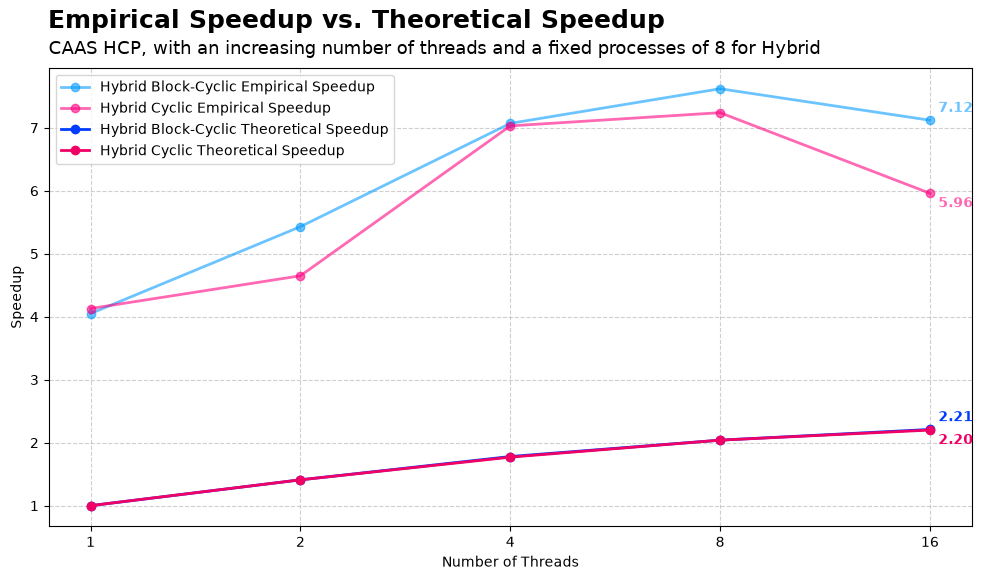

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "task3.xlsx"

# Read the file without headers to explicitly slice the exact block of data
# This ignores merged headers and safely targets the specific section
df_raw = pd.read_excel(file_name, sheet_name="Data", header=None)

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================
# Target Columns based on the Excel layout:
# Col 0: T/P (Number of Processes/Threads)
# Col 24: Hybrid Block-Cyclic Empirical Speedup
# Col 25: Hybrid Block-Cyclic Theoretical (A) Speedup
# Col 29: Hybrid Cyclic Empirical Speedup
# Col 30: Hybrid Cyclic Theoretical (A) Speedup
target_cols = [0, 24, 25, 29, 30]

# Pandas is 0-indexed, so rows 38 to 44 correspond to iloc[37:44] (T/P 1 through 64)
df_clean = df_raw.iloc[37:42, target_cols].copy()

# Rename to explicit names for easy plotting
df_clean.columns = [
    'Number of Processes',
    'Hybrid Block-Cyclic Empirical Speedup',
    'Hybrid Block-Cyclic Theoretical Speedup',
    'Hybrid Cyclic Empirical Speedup',
    'Hybrid Cyclic Theoretical Speedup'
]

# Convert all columns to numeric to wipe out any string artifacts or formula references
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Ensure X-axis is clean and sorted
df_clean = df_clean.dropna(subset=['Number of Processes'])
df_clean = df_clean.sort_values(by='Number of Processes').reset_index(drop=True)

# Round the speedup columns to 2 decimal places
for col in df_clean.columns[1:]:
    df_clean[col] = df_clean[col].round(2)

# ==========================================
# 3. SETUP AND PLOT
# ==========================================
plt.figure(figsize=(10, 6))

# Define exact colors requested: 
# Light Alpha Hex for Empirical, Dark Solid Hex for Theoretical
colors = ["#0099FF93", "#FF008097", "#003CFF", "#F10065"]
x_standard = [1, 2, 4, 8, 16] # Logarithmic ticks up to 64

# Define the lines to plot in the exact order of the colors array
lines_to_plot = [
    'Hybrid Block-Cyclic Empirical Speedup',
    'Hybrid Cyclic Empirical Speedup',
    'Hybrid Block-Cyclic Theoretical Speedup',
    'Hybrid Cyclic Theoretical Speedup'
]

# Specific text offsets to prevent overlapping labels at the end of the graph
text_offsets = {
    'Hybrid Block-Cyclic Empirical Speedup': (6, 6),    # Push up
    'Hybrid Cyclic Empirical Speedup': (6, -10),        # Push down
    'Hybrid Block-Cyclic Theoretical Speedup': (6, 6),  # Push up
    'Hybrid Cyclic Theoretical Speedup': (6, -10)       # Push down
}

for idx, line_name in enumerate(lines_to_plot):
    color = colors[idx]
    
    # Isolate valid data points for this specific line (drops empty cells like 32 & 64)
    valid_data = df_clean[['Number of Processes', line_name]].dropna()
    
    if not valid_data.empty:
        x_vals = valid_data['Number of Processes'].tolist()
        y_vals = valid_data[line_name].tolist()
        
        # Plot the line with dot points
        plt.plot(x_vals, y_vals, marker='o', label=line_name, color=color, linewidth=2)
        
        # Annotate the absolute last valid dot point safely
        last_x = x_vals[-1]
        last_y = y_vals[-1]
        text_offset = text_offsets.get(line_name, (6, -4))
                
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=text_offset,
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

# Formatting Titles (Aligned to the left)
plt.suptitle("Empirical Speedup vs. Theoretical Speedup", fontweight='bold', fontsize=18, x=0.053, y=0.96, ha='left')
plt.title("CAAS HCP, with an increasing number of threads and a fixed processes of 8 for Hybrid", fontsize=13, pad=10, loc='left')

# Axis labels and legend
plt.xlabel("Number of Threads")
plt.ylabel("Speedup")
plt.legend(loc='upper left')

# Set X-axis to a Base-2 Logarithmic scale
plt.xscale('log', base=2)
plt.xticks(x_standard, labels=[str(t) for t in x_standard])

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("Empirical_vs_Theoretical_Hybrid_Processes8.png", dpi=300)
plt.show()

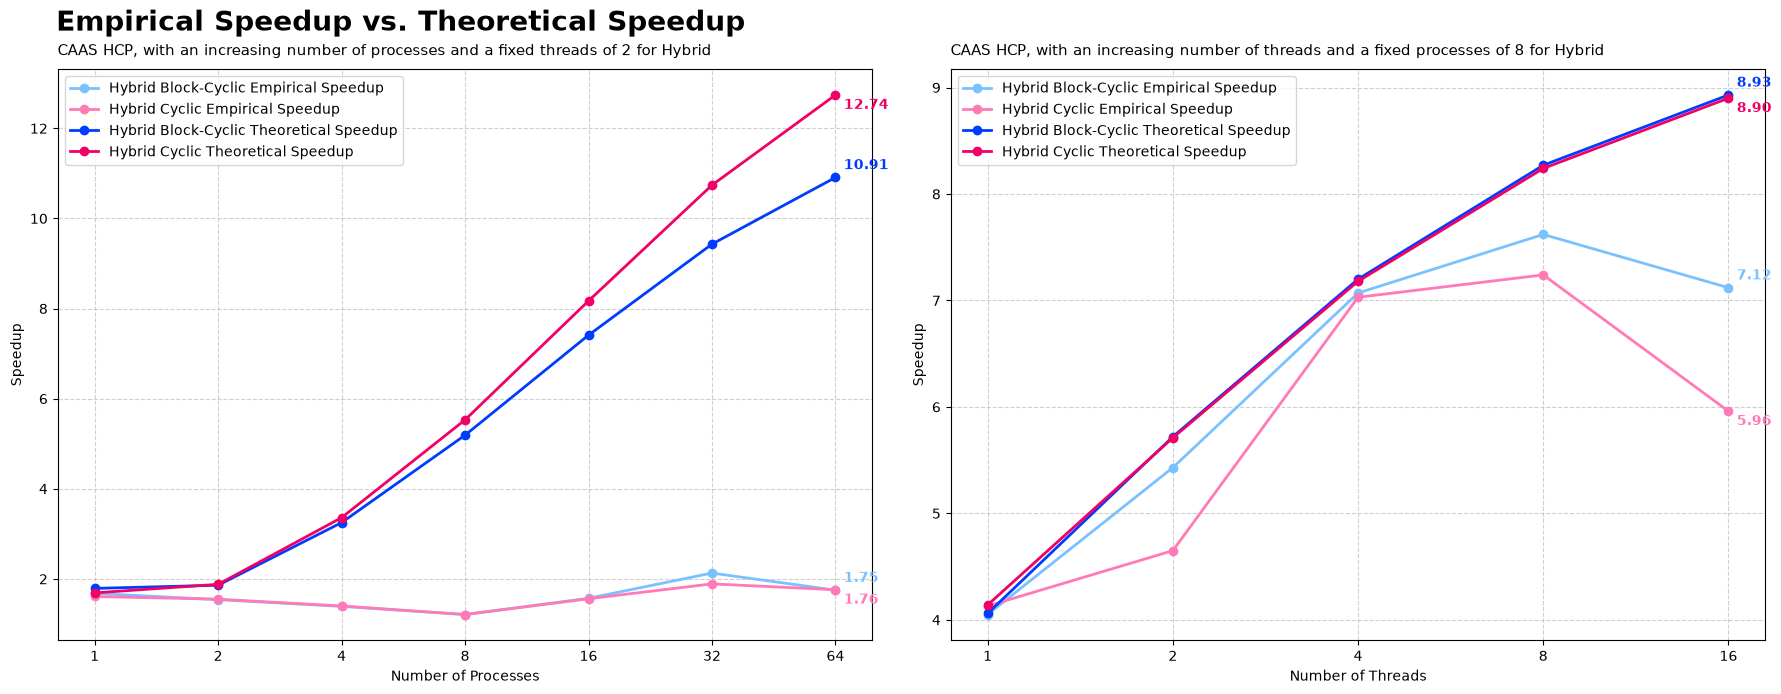

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "task3.xlsx"

# Read the file without headers
df_raw = pd.read_excel(file_name, sheet_name="Data", header=None)

# ==========================================
# 2. DATA CLEANING & EXTRACTION
# ==========================================

# --- DATA PREP: LEFT GRAPH (Processes Increase) ---
# If your data prints as NaN, these column numbers need to be adjusted!
target_cols_1 = [0, 14, 15, 19, 20] 
df_left = df_raw.iloc[37:45, target_cols_1].copy()
df_left.columns = [
    'Number of Processes',
    'Hybrid Block-Cyclic Empirical Speedup',
    'Hybrid Block-Cyclic Theoretical Speedup',
    'Hybrid Cyclic Empirical Speedup',
    'Hybrid Cyclic Theoretical Speedup'
]
# Clean and round
for col in df_left.columns:
    df_left[col] = pd.to_numeric(df_left[col], errors='coerce')
df_left = df_left.dropna(subset=['Number of Processes'])
df_left = df_left[(df_left['Number of Processes'] >= 1) & (df_left['Number of Processes'] <= 64)]
df_left = df_left.sort_values(by='Number of Processes').reset_index(drop=True)
for col in df_left.columns[1:]:
    df_left[col] = df_left[col].round(2)

# --- DATA PREP: RIGHT GRAPH (Threads Increase) ---
# If your data prints as NaN, these column numbers need to be adjusted!
target_cols_2 = [0, 24, 25, 29, 30]
df_right = df_raw.iloc[37:42, target_cols_2].copy()
df_right.columns = [
    'Number of Threads',
    'Hybrid Block-Cyclic Empirical Speedup',
    'Hybrid Block-Cyclic Theoretical Speedup',
    'Hybrid Cyclic Empirical Speedup',
    'Hybrid Cyclic Theoretical Speedup'
]
# Clean and round
for col in df_right.columns:
    df_right[col] = pd.to_numeric(df_right[col], errors='coerce')
df_right = df_right.dropna(subset=['Number of Threads'])
df_right = df_right.sort_values(by='Number of Threads').reset_index(drop=True)
for col in df_right.columns[1:]:
    df_right[col] = df_right[col].round(2)


# ==========================================
# 3. SETUP AND PLOT
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Fixed standard 6-character Hex colors (Light for Empirical, Dark for Theoretical)
colors = ["#7AC1FF", "#FF7AB6", "#003CFF", "#F10065"] 
lines_to_plot = [
    'Hybrid Block-Cyclic Empirical Speedup',
    'Hybrid Cyclic Empirical Speedup',
    'Hybrid Block-Cyclic Theoretical Speedup',
    'Hybrid Cyclic Theoretical Speedup'
]
text_offsets = {
    'Hybrid Block-Cyclic Empirical Speedup': (6, 6),    
    'Hybrid Cyclic Empirical Speedup': (6, -10),        
    'Hybrid Block-Cyclic Theoretical Speedup': (6, 6),  
    'Hybrid Cyclic Theoretical Speedup': (6, -10)       
}

# --- MAIN OVERALL TITLE ---
fig.suptitle("Empirical Speedup vs. Theoretical Speedup", fontweight='bold', fontsize=20, x=0.034, y=0.985, ha='left')

# ------------------------------------------
# --- PLOT LEFT GRAPH (ax1) ---
# ------------------------------------------
x_standard_1 = [1, 2, 4, 8, 16, 32, 64]
x_vals_1 = df_left['Number of Processes'].tolist()

for idx, line_name in enumerate(lines_to_plot):
    color = colors[idx]
    y_vals = df_left[line_name].tolist()
    
    # Only plot if we have valid data
    if len(x_vals_1) > 0 and len(y_vals) > 0:
        ax1.plot(x_vals_1, y_vals, marker='o', label=line_name, color=color, linewidth=2)
        
        if not pd.isna(y_vals[-1]):
            text_offset = text_offsets.get(line_name, (6, -4))
            ax1.annotate(f'{y_vals[-1]:.2f}', 
                         xy=(x_vals_1[-1], y_vals[-1]), 
                         xytext=text_offset,
                         textcoords='offset points',
                         color=color, 
                         fontweight='bold')

ax1.set_title("CAAS HCP, with an increasing number of processes and a fixed threads of 2 for Hybrid", fontsize=11, loc='left', pad=10)
ax1.set_xlabel("Number of Processes")
ax1.set_ylabel("Speedup")
ax1.set_xscale('log', base=2)
ax1.set_xticks(x_standard_1)
ax1.set_xticklabels([str(t) for t in x_standard_1])
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# ------------------------------------------
# --- PLOT RIGHT GRAPH (ax2) ---
# ------------------------------------------
x_standard_2 = [1, 2, 4, 8, 16]

for idx, line_name in enumerate(lines_to_plot):
    color = colors[idx]
    
    valid_data = df_right[['Number of Threads', line_name]].dropna()
    
    if not valid_data.empty:
        x_vals_2 = valid_data['Number of Threads'].tolist()
        y_vals_2 = valid_data[line_name].tolist()
        
        ax2.plot(x_vals_2, y_vals_2, marker='o', label=line_name, color=color, linewidth=2)
        
        last_x, last_y = x_vals_2[-1], y_vals_2[-1]
        text_offset = text_offsets.get(line_name, (6, -4))
                
        ax2.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=text_offset,
                     textcoords='offset points',
                     color=color, 
                     fontweight='bold')

ax2.set_title("CAAS HCP, with an increasing number of threads and a fixed processes of 8 for Hybrid", fontsize=11, loc='left', pad=10)
ax2.set_xlabel("Number of Threads")
ax2.set_ylabel("Speedup")
ax2.set_xscale('log', base=2)
ax2.set_xticks(x_standard_2)
ax2.set_xticklabels([str(t) for t in x_standard_2])
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

# Finalize Layout & Save
plt.tight_layout()
fig.subplots_adjust(top=0.90) 
plt.savefig("task3_Hybrid_7b.png", dpi=300, bbox_inches='tight')
plt.show()